In [57]:
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt
from collections import Counter

import torch
from torch.nn.utils.rnn import pad_sequence
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, TimeDistributed, Dropout, SpatialDropout1D, Input, Layer
from tensorflow.keras import Input
from tensorflow.keras.callbacks import EarlyStopping
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
import tensorflow.keras.backend as K

## 1. Download dataset and EDA

In [2]:
path = kagglehub.dataset_download("alaakhaled/conll003-englishversion")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Chiara\.cache\kagglehub\datasets\alaakhaled\conll003-englishversion\versions\1


In [3]:
print(os.listdir(path))

['metadata', 'test.txt', 'train.txt', 'valid.txt']


In [4]:
# Check rows

train_path = os.path.join(path, "train.txt")

with open(train_path, "r", encoding="utf-8") as f:
    for _ in range(30):
        print(f.readline().strip())

-DOCSTART- -X- -X- O

EU NNP B-NP B-ORG
rejects VBZ B-VP O
German JJ B-NP B-MISC
call NN I-NP O
to TO B-VP O
boycott VB I-VP O
British JJ B-NP B-MISC
lamb NN I-NP O
. . O O

Peter NNP B-NP B-PER
Blackburn NNP I-NP I-PER

BRUSSELS NNP B-NP B-LOC
1996-08-22 CD I-NP O

The DT B-NP O
European NNP I-NP B-ORG
Commission NNP I-NP I-ORG
said VBD B-VP O
on IN B-PP O
Thursday NNP B-NP O
it PRP B-NP O
disagreed VBD B-VP O
with IN B-PP O
German JJ B-NP B-MISC
advice NN I-NP O
to TO B-PP O


I need:
* Token in column 0
* NER tag in column 3

In [5]:
# To open data in a clean way

def load_conll(filepath):
    
    sentences = []
    labels = []

    tokens = []
    ner_tags = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line == "": # end of the sentence
                if tokens:
                    sentences.append(tokens)
                    labels.append(ner_tags)
                    tokens = []
                    ner_tags = []
                continue

            if line.startswith("-DOCSTART-"):
                continue

            parts = line.split()
            token = parts[0]
            ner = parts[-1]

            tokens.append(token)
            ner_tags.append(ner)

    return sentences, labels
                

In [6]:
train_sentences, train_labels = load_conll(os.path.join(path, "train.txt"))
test_sentences, test_labels = load_conll(os.path.join(path, "test.txt"))
valid_sentences, valid_labels = load_conll(os.path.join(path, "valid.txt"))

print("Train: ", len(train_sentences))
print("Test: ", len(test_sentences))
print("Validation: ", len(valid_sentences))

Train:  14041
Test:  3453
Validation:  3250


In [7]:
print("First sentence:")
print(train_sentences[0])
print(train_labels[0])

First sentence:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


In [8]:
# Check the tags

all_tags = [tag for seq in train_labels for tag in seq]
print(Counter(all_tags))

Counter({'O': 169578, 'B-LOC': 7140, 'B-PER': 6600, 'B-ORG': 6321, 'I-PER': 4528, 'I-ORG': 3704, 'B-MISC': 3438, 'I-LOC': 1157, 'I-MISC': 1155})


To understand the labels:
* PER = person
* LOC = locality
* ORG = organization
* MISC = miscellaneous

Moreover
* B = begins for the entity
* I = continuity for the same entity

## 2. Text pre-processing

### 2.1. Vocabulary

Built from the training set.

In [9]:
word_counter = Counter()

for sentence in train_sentences:
    word_counter.update(sentence)

In [10]:
# Special tokens

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}

In [11]:
for word in word_counter:
    vocab[word] = len(vocab)

print("Vocabulary size: ", len(vocab))

Vocabulary size:  23625


### 2.2. Build label-index correspondance

In [12]:
unique_tags = sorted(set(tag for seq in train_labels for tag in seq))

tag2idx = {tag: idx for idx, tag in enumerate(unique_tags)}
idx2tag = {idx: tag for tag, idx in tag2idx.items()}

print("Tag mapping: ", tag2idx)

Tag mapping:  {'B-LOC': 0, 'B-MISC': 1, 'B-ORG': 2, 'B-PER': 3, 'I-LOC': 4, 'I-MISC': 5, 'I-ORG': 6, 'I-PER': 7, 'O': 8}


### 2.3. Converts words and tags into index

Each word of the sentence is mapped to a int index (0 index for padding and 1 index for unknown). Each label is mapped using the mapping before.

In [13]:
def encode_sentences(sentences, vocab):
    
    encoded = []
    
    for sentence in sentences:
        encoded.append([vocab[word] if word in vocab else vocab[UNK_TOKEN] for word in sentence])

    return encoded

In [14]:
def encode_labels(labels, tag2idx):
    return[[tag2idx[tag] for tag in seq] for seq in labels]

In [15]:
train_encoded = encode_sentences(train_sentences, vocab)
train_label_encoded = encode_labels(train_labels, tag2idx)

valid_encoded = encode_sentences(valid_sentences, vocab)
valid_label_encoded = encode_labels(valid_labels, tag2idx)

test_encoded = encode_sentences(test_sentences, vocab)
test_label_encoded = encode_labels(test_labels, tag2idx)

In [16]:
train_label_encoded[0]

[2, 8, 1, 8, 8, 8, 1, 8, 8]

In [17]:
train_encoded[0]

[2, 3, 4, 5, 6, 7, 8, 9, 10]

### 2.4. Padding

For batches with same length.

In [18]:
max_len = max(len(seq) for seq in train_encoded)
print("Max length (train): ", max_len)

Max length (train):  113


In [19]:
def pad_data(encoded_sentences, encoded_labels, max_len):
    
    padded_sentences = []
    padded_labels = []
    
    for seq, lab in zip(encoded_sentences, encoded_labels):
        
        # Truncate if too long
        seq = seq[:max_len]
        lab = lab[:max_len]

        # Padding if too short
        seq = seq + [vocab["<PAD>"]] * (max_len - len(seq))
        lab = lab + [tag2idx["O"]] * (max_len - len(lab))
        
        padded_sentences.append(seq)
        padded_labels.append(lab)
    
    return torch.tensor(padded_sentences), torch.tensor(padded_labels)

In [20]:
train_padded, train_labels_padded = pad_data(train_encoded, train_label_encoded, max_len)
valid_padded, valid_labels_padded = pad_data(valid_encoded, valid_label_encoded, max_len)
test_padded, test_labels_padded = pad_data(test_encoded, test_label_encoded, max_len)

print(train_padded.shape)
print(valid_padded.shape)
print(test_padded.shape)

torch.Size([14041, 113])
torch.Size([3250, 113])
torch.Size([3453, 113])


In [21]:
print(train_labels_padded.shape)

torch.Size([14041, 113])


In [22]:
train_padded[0]

tensor([ 2,  3,  4,  5,  6,  7,  8,  9, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0])

In [23]:
train_labels_padded[0]

tensor([2, 8, 1, 8, 8, 8, 1, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8])

In [24]:
# Convert to numpy

train_padded = train_padded.numpy()
valid_padded = valid_padded.numpy()
test_padded = test_padded.numpy()

train_labels_padded = train_labels_padded.numpy()
valid_labels_padded = valid_labels_padded.numpy()
test_labels_padded = test_labels_padded.numpy()

## 3. Modelling - BiLSTM

In [25]:
# Parameters

vocab_size = len(vocab)
embedding_dim = 100
hidden_dim = 128
num_tags = len(tag2idx)

In [26]:
# Model

model = Sequential()

model.add(Input(shape=(train_padded.shape[1],)))

model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=train_padded.shape[1], mask_zero=True))  # Embedding layer
model.add(Bidirectional(LSTM(hidden_dim, return_sequences=True)))  # BiLSTM
model.add(TimeDistributed(Dense(len(tag2idx), activation="softmax")))  # Classifier for each token

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

C:\Users\Chiara\anaconda3\envs\cv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 113, 100)            │       2,362,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 113, 256)            │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 113, 9)              │           2,313 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,599,309 (9.92 MB)

 Trainable params: 2,599,309 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Training

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(train_padded, train_labels_padded, validation_data=(valid_padded, valid_labels_padded), epochs=15, batch_size=32, callbacks=[early_stop])

Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.8698 - loss: 0.4940 - val_accuracy: 0.9240 - val_loss: 0.2850
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9680 - loss: 0.1160 - val_accuracy: 0.9571 - val_loss: 0.1604
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9898 - loss: 0.0407 - val_accuracy: 0.9593 - val_loss: 0.1525
Epoch 4/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9949 - loss: 0.0202 - val_accuracy: 0.9594 - val_loss: 0.1567
Epoch 5/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.9967 - loss: 0.0123 - val_accuracy: 0.9587 - val_loss: 0.1796
Epoch 6/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9979 - loss: 0.0079 - val_accuracy: 0.9599 - val_loss: 0.1942


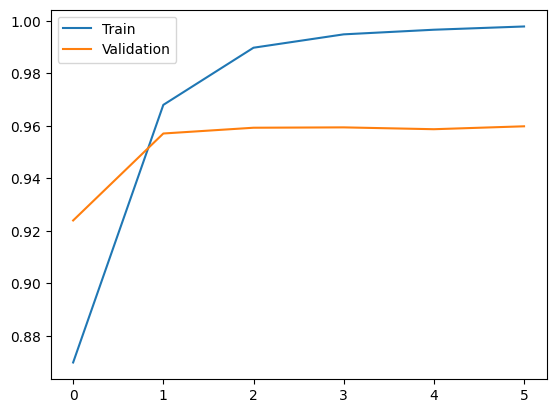

In [29]:
# Plot accuracies

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.legend()
plt.show()

However, accuracy is not reliable because most ok tokens are "O". So the model could predict always "O".

I need other metrics.

In [32]:
# Predictions

test_predictions = model.predict(test_padded)
test_pred_labels = np.argmax(test_predictions, axis=-1)

print(test_predictions.shape)
print(test_pred_labels.shape)

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
(3453, 113, 9)
(3453, 113)


In [33]:
# Re-build sentences

true_seq = []
pred_seq = []

for i in range(len(test_sentences)):

    length = len(test_sentences[i])
    
    true_tags = [idx2tag[int(idx)] for idx in test_labels_padded[i][:length]]
    pred_tags = [idx2tag[int(idx)] for idx in test_pred_labels[i][:length]]

    true_seq.append(true_tags)
    pred_seq.append(pred_tags)

In [34]:
print(classification_report(true_seq, pred_seq))

              precision    recall  f1-score   support

         LOC       0.82      0.77      0.79      1667
        MISC       0.67      0.66      0.67       702
         ORG       0.63      0.58      0.61      1661
         PER       0.76      0.56      0.65      1616

   micro avg       0.73      0.64      0.68      5646
   macro avg       0.72      0.64      0.68      5646
weighted avg       0.73      0.64      0.68      5646



If I have a look at the F1-score, I see that results are not exceptional.

I try to make the performance better.

## 4. Add Dropout layers + another LSTM layer

In [36]:
embedding_dim = 100
hidden_dim = 128

model2 = Sequential()

model2.add(Input(shape=(max_len,)))
model2.add(Embedding(input_dim=len(vocab), output_dim=embedding_dim, mask_zero=True))
model2.add(SpatialDropout1D(0.3))  # On the embedding layer, it switches off entire features over all the vectors
model2.add(Bidirectional(LSTM(hidden_dim, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)))
model2.add(Bidirectional(LSTM(hidden_dim, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)))
model2.add(Dropout(0.3))
model2.add(TimeDistributed(Dense(len(tag2idx), activation="softmax")))

model2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [37]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 113, 100)            │       2,362,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (None, 113, 100)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 113, 256)            │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 113, 256)            │         394,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 113, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 113, 9)              │           2,313 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,993,549 (11.42 MB)

 Trainable params: 2,993,549 (11.42 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Training

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history2 = model2.fit(train_padded, train_labels_padded, validation_data=(valid_padded, valid_labels_padded), epochs=15, batch_size=32, callbacks=[early_stop])

Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 158s 345ms/step - accuracy: 0.8618 - loss: 0.5354 - val_accuracy: 0.9073 - val_loss: 0.3080
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 151s 343ms/step - accuracy: 0.9486 - loss: 0.1628 - val_accuracy: 0.9536 - val_loss: 0.1709
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 151s 344ms/step - accuracy: 0.9793 - loss: 0.0744 - val_accuracy: 0.9519 - val_loss: 0.1625
Epoch 4/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 151s 343ms/step - accuracy: 0.9885 - loss: 0.0440 - val_accuracy: 0.9556 - val_loss: 0.1502
Epoch 5/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 150s 342ms/step - accuracy: 0.9918 - loss: 0.0310 - val_accuracy: 0.9551 - val_loss: 0.1510
Epoch 6/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 150s 343ms/step - accuracy: 0.9935 - loss: 0.0242 - val_accuracy: 0.9509 - val_loss: 0.1624
Epoch 7/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 151s 343ms/step - accuracy: 0.9944 - loss: 0.0201 - val_accuracy: 0.9580 - val_loss: 0.1593


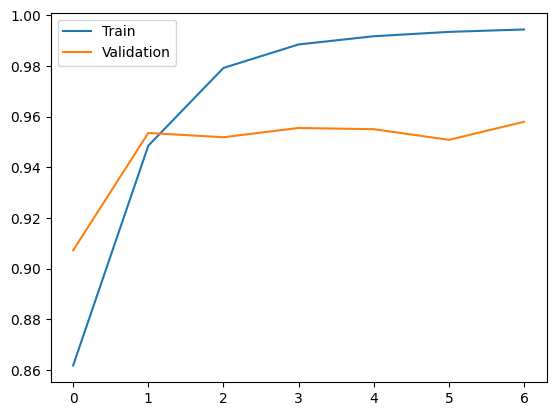

In [45]:
# Plot accuracies

plt.plot(history2.history["accuracy"], label="Train")
plt.plot(history2.history["val_accuracy"], label="Validation")
plt.legend()
plt.show()

In [46]:
# Predictions

test_predictions2 = model2.predict(test_padded)
test_pred_labels2 = np.argmax(test_predictions2, axis=-1)

print(test_predictions2.shape)
print(test_pred_labels2.shape)

108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
(3453, 113, 9)
(3453, 113)


In [47]:
# Re-build sentences

true_seq2 = []
pred_seq2 = []

for i in range(len(test_sentences)):

    length = len(test_sentences[i])
    
    true_tags2 = [idx2tag[int(idx)] for idx in test_labels_padded[i][:length]]
    pred_tags2 = [idx2tag[int(idx)] for idx in test_pred_labels2[i][:length]]

    true_seq2.append(true_tags2)
    pred_seq2.append(pred_tags2)

In [48]:
print(classification_report(true_seq2, pred_seq2))

              precision    recall  f1-score   support

         LOC       0.77      0.73      0.75      1667
        MISC       0.61      0.63      0.62       702
         ORG       0.56      0.71      0.62      1661
         PER       0.71      0.75      0.73      1616

   micro avg       0.66      0.72      0.69      5646
   macro avg       0.66      0.71      0.68      5646
weighted avg       0.67      0.72      0.69      5646



The recall has increased, but the precision has decreased. I try another attempt to make the model more performative.

I use another strategy $\rightarrow$ pre-trained GloVe with fine tuning.

## 5. Pre-trained GloVe

In [89]:
# Upload the vectors

embedding_dim = 100
glove_path = "C:\\Users\\Chiara\\Desktop\\LEARN\\glove.6B\\glove.6B.100d.txt"

embeddings_index = {}

with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

In [90]:
# Creation of the embedding matrix

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in vocab.items():
    if word.lower() in embeddings_index:
        embedding_matrix[i] = embeddings_index[word.lower()]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))

In [91]:
embedding_matrix.shape

(23625, 100)

In [92]:
# Model

model3 = Sequential()

model3.add(Input(shape=(max_len,)))
model3.add(Embedding(input_dim=len(vocab), output_dim=embedding_dim, weights=[embedding_matrix], trainable=False, mask_zero=True))
model3.add(Bidirectional(LSTM(hidden_dim, return_sequences=True)))
model3.add(TimeDistributed(Dense(len(tag2idx), activation="softmax")))

model3.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [93]:
model3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ (None, 113, 100)            │       2,362,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_8 (Bidirectional)      │ (None, 113, 256)            │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_4 (TimeDistributed) │ (None, 113, 9)              │           2,313 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,599,309 (9.92 MB)

 Trainable params: 236,809 (925.04 KB)

 Non-trainable params: 2,362,500 (9.01 MB)

In [94]:
# Training

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history3 = model3.fit(train_padded, train_labels_padded, validation_data=(valid_padded, valid_labels_padded), epochs=15, batch_size=32, callbacks=[early_stop])

Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.9055 - loss: 0.3420 - val_accuracy: 0.9360 - val_loss: 0.2372
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9551 - loss: 0.1556 - val_accuracy: 0.9506 - val_loss: 0.1821
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9662 - loss: 0.1159 - val_accuracy: 0.9553 - val_loss: 0.1598
Epoch 4/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9728 - loss: 0.0923 - val_accuracy: 0.9584 - val_loss: 0.1474
Epoch 5/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9777 - loss: 0.0752 - val_accuracy: 0.9592 - val_loss: 0.1462
Epoch 6/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9824 - loss: 0.0611 - val_accuracy: 0.9604 - val_loss: 0.1380
Epoch 7/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9855 - loss: 0.0508 - val_accuracy: 0.9608 - val_loss: 0.1437
Epoch 8/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9888 - loss: 0.0401 - 

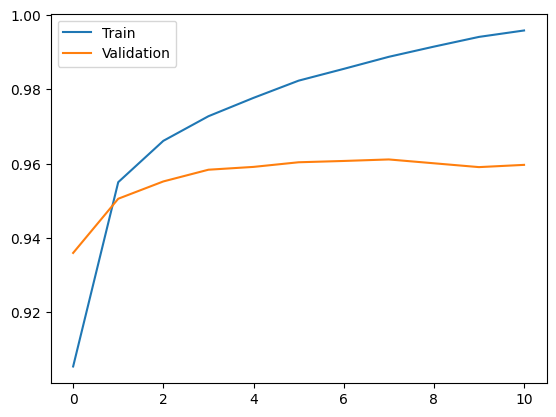

In [95]:
# Plot accuracies

plt.plot(history3.history["accuracy"], label="Train")
plt.plot(history3.history["val_accuracy"], label="Validation")
plt.legend()
plt.show()

In [96]:
# Predictions

test_predictions3 = model3.predict(test_padded)
test_pred_labels3 = np.argmax(test_predictions3, axis=-1)

print(test_predictions3.shape)
print(test_pred_labels3.shape)

108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
(3453, 113, 9)
(3453, 113)


In [97]:
# Re-build sentences

true_seq3 = []
pred_seq3 = []

for i in range(len(test_sentences)):

    length = len(test_sentences[i])
    
    true_tags3 = [idx2tag[int(idx)] for idx in test_labels_padded[i][:length]]
    pred_tags3 = [idx2tag[int(idx)] for idx in test_pred_labels3[i][:length]]

    true_seq3.append(true_tags3)
    pred_seq3.append(pred_tags3)

In [98]:
print(classification_report(true_seq3, pred_seq3))

              precision    recall  f1-score   support

         LOC       0.86      0.78      0.82      1667
        MISC       0.63      0.66      0.64       702
         ORG       0.71      0.59      0.65      1661
         PER       0.64      0.82      0.72      1616

   micro avg       0.72      0.72      0.72      5646
   macro avg       0.71      0.71      0.71      5646
weighted avg       0.73      0.72      0.72      5646



The F1-score is improved with respect to the original model without modifications. 